# Customer Segmentation using K-Means Clustering



## 1. Install and import the required libraries


In [1]:
!pip -q install kagglehub

In [2]:
import os
import re
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_context("notebook")
np.random.seed(42)

## 2. Download the dataset from Kaggle


In [3]:
dataset_path = kagglehub.dataset_download("hanaksoy/customer-purchasing-behaviors")
print("Dataset downloaded to:", dataset_path)

csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

100%|██████████| 1.39k/1.39k [00:00<00:00, 2.53MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/hanaksoy/customer-purchasing-behaviors/versions/1
CSV files found: ['/root/.cache/kagglehub/datasets/hanaksoy/customer-purchasing-behaviors/versions/1/Customer Purchasing Behaviors.csv']


## 3. Load the dataset


In [4]:
file_path = csv_files[0]
df = pd.read_csv(file_path)
print("Loaded file:", os.path.basename(file_path))
df.head()

Loaded file: Customer Purchasing Behaviors.csv


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


## 4. Basic data understanding


In [5]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (238, 7)

Column names:
['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score', 'region', 'purchase_frequency']

Data types:


,0
user_id,int64
age,int64
annual_income,int64
purchase_amount,int64
loyalty_score,float64
region,object
purchase_frequency,int64



Missing values:


,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0



Duplicate rows: 0


## 5. Clean column names

In [6]:
def clean_col_name(col):
    col = col.strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

df.columns = [clean_col_name(col) for col in df.columns]
print(df.columns.tolist())

['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score', 'region', 'purchase_frequency']


## 6. Identify the important feature columns


In [7]:
expected_aliases = {
    "customer_id": ["customer_id", "user_id", "id"],
    "age": ["age"],
    "annual_income": ["annual_income", "income", "yearly_income"],
    "purchase_amount": ["purchase_amount", "amount_spent", "spending", "purchase_value"],
    "purchase_frequency": ["purchase_frequency", "frequency", "visit_frequency"],
    "loyalty_score": ["loyalty_score", "loyalty", "score"],
    "region": ["region", "area", "location"]
}

resolved = {}
for standard_name, aliases in expected_aliases.items():
    for alias in aliases:
        if alias in df.columns:
            resolved[standard_name] = alias
            break

resolved

{'customer_id': 'user_id',
 'age': 'age',
 'annual_income': 'annual_income',
 'purchase_amount': 'purchase_amount',
 'purchase_frequency': 'purchase_frequency',
 'loyalty_score': 'loyalty_score',
 'region': 'region'}

## 7. Handle missing values and duplicates


In [8]:
df = df.drop_duplicates().copy()

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:")
display(df.isnull().sum())
print("New shape:", df.shape)

Remaining missing values:


,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


New shape: (238, 7)


## 8. Descriptive statistics


In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,238.0,NaN,NaN,NaN,119.5,68.848868,1.0,60.25,119.5,178.75,238.0
age,238.0,NaN,NaN,NaN,38.676471,9.351118,22.0,31.0,39.0,46.75,55.0
annual_income,238.0,NaN,NaN,NaN,57407.563025,11403.875717,30000.0,50000.0,59000.0,66750.0,75000.0
purchase_amount,238.0,NaN,NaN,NaN,425.630252,140.052062,150.0,320.0,440.0,527.5,640.0
loyalty_score,238.0,NaN,NaN,NaN,6.794118,1.899047,3.0,5.5,7.0,8.275,9.5
region,238,4,North,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_frequency,238.0,NaN,NaN,NaN,19.798319,4.562884,10.0,17.0,20.0,23.0,28.0


## 9. Univariate analysis


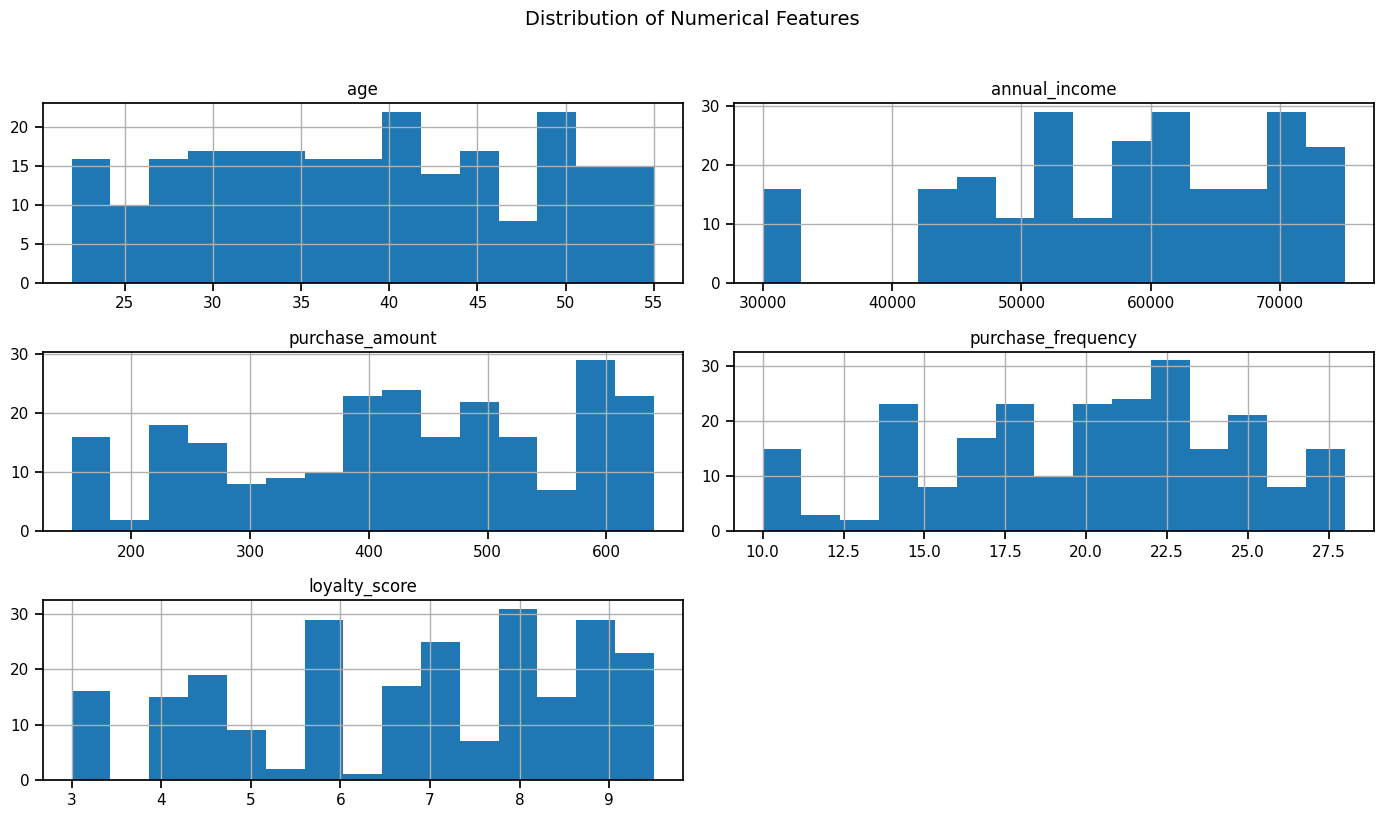

In [10]:
eda_numeric = [resolved[c] for c in ["age", "annual_income", "purchase_amount", "purchase_frequency", "loyalty_score"] if c in resolved]

if eda_numeric:
    df[eda_numeric].hist(figsize=(14, 8), bins=15)
    plt.suptitle("Distribution of Numerical Features", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No expected numerical columns were found for the histogram plots.")

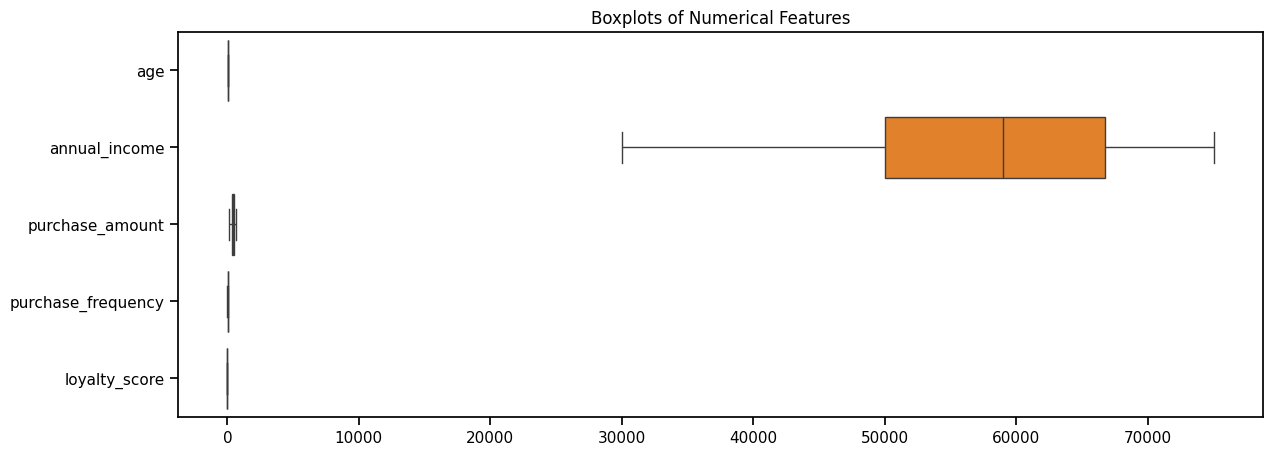

In [11]:
if eda_numeric:
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=df[eda_numeric], orient="h")
    plt.title("Boxplots of Numerical Features")
    plt.show()
else:
    print("No expected numerical columns were found for the boxplots.")

## 10. Bivariate analysis


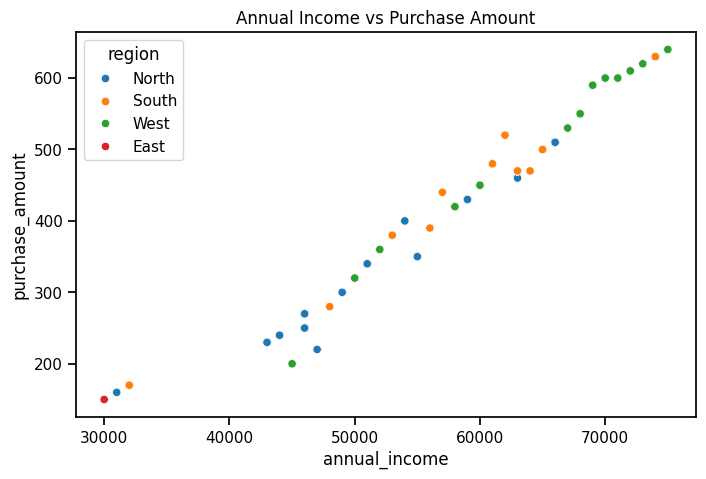

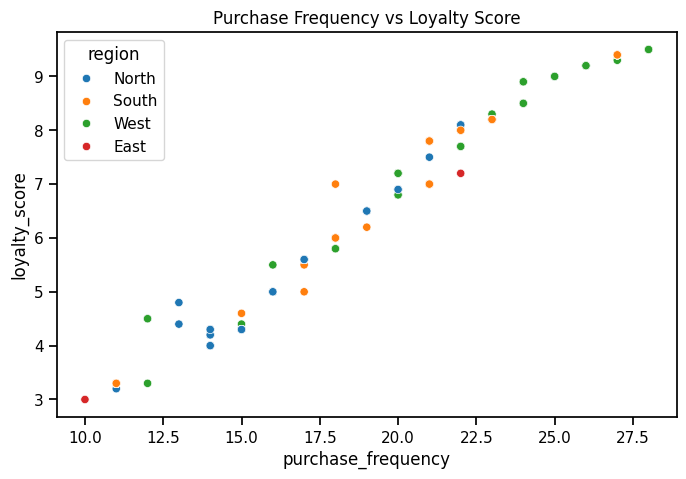

In [12]:
income_col = resolved.get("annual_income")
amount_col = resolved.get("purchase_amount")
freq_col = resolved.get("purchase_frequency")
loyalty_col = resolved.get("loyalty_score")
region_col = resolved.get("region")

if income_col and amount_col:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=income_col, y=amount_col, hue=region_col if region_col else None)
    plt.title("Annual Income vs Purchase Amount")
    plt.show()
else:
    print("Income and purchase amount columns were not both found.")

if freq_col and loyalty_col:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=freq_col, y=loyalty_col, hue=region_col if region_col else None)
    plt.title("Purchase Frequency vs Loyalty Score")
    plt.show()
else:
    print("Purchase frequency and loyalty score columns were not both found.")

## 11. Select features for clustering


In [13]:
feature_candidates = []
for key in ["age", "annual_income", "purchase_amount", "purchase_frequency", "loyalty_score", "region"]:
    if key in resolved:
        feature_candidates.append(resolved[key])

print("Selected feature columns:", feature_candidates)

if len(feature_candidates) < 2:
    raise ValueError("Not enough usable feature columns found for clustering.")

X = df[feature_candidates].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Selected feature columns: ['age', 'annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score', 'region']
Numeric features: ['age', 'annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score']
Categorical features: ['region']


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (238, 8)


## 12. Find the optimal number of clusters
We use:
- **Elbow Method**: to observe inertia drop
- **Silhouette Score**: to measure cluster separation quality

In [15]:
k_values = list(range(2, 11))
inertia_scores = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_processed)
    inertia_scores.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))

results = pd.DataFrame({
    "k": k_values,
    "inertia": inertia_scores,
    "silhouette_score": silhouette_scores
})

display(results)

,k,inertia,silhouette_score
0,2,482.082530,0.520983
1,3,290.627751,0.470883
2,4,213.231282,0.435627
3,5,168.286682,0.473670
4,6,139.288987,0.488721
5,7,116.478336,0.515043
6,8,94.028098,0.568938
7,9,77.307610,0.586041
8,10,63.077680,0.632404


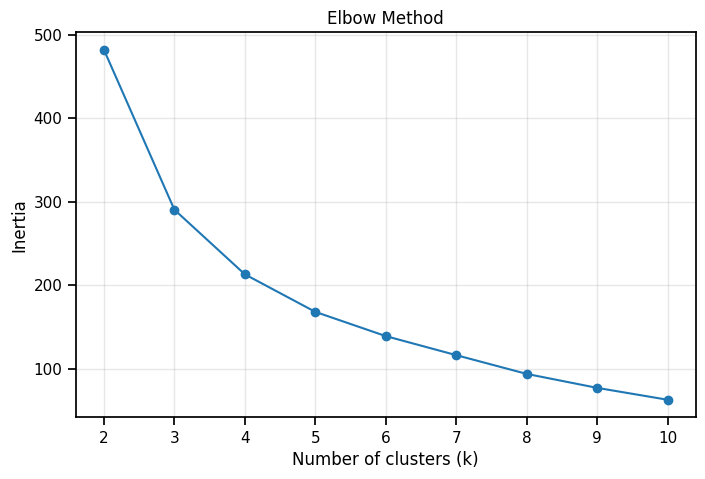

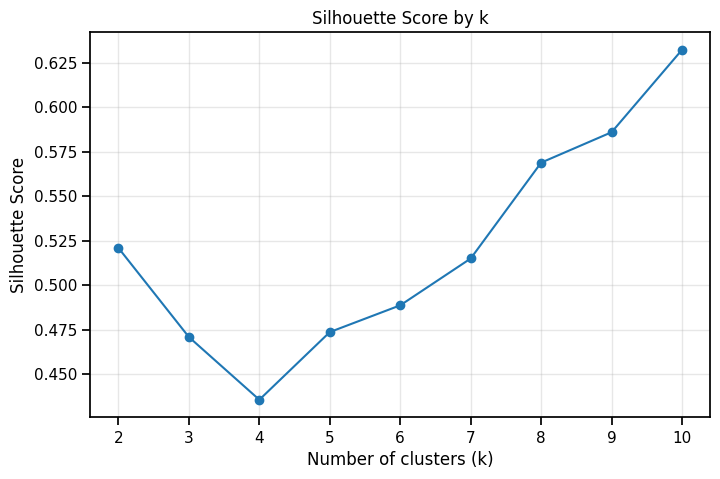

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_scores, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.grid(alpha=0.3)
plt.show()

## 13. Train the final K-Means model


In [17]:
best_k = int(results.loc[results["silhouette_score"].idxmax(), "k"])
print("Chosen k based on best silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_processed)

df["cluster"] = cluster_labels
df.head()

Chosen k based on best silhouette score: 10


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency,cluster
0,1,25,45000,200,4.5,North,12,0
1,2,34,55000,350,7.0,South,18,3
2,3,45,65000,500,8.0,West,22,5
3,4,22,30000,150,3.0,East,10,4
4,5,29,47000,220,4.8,North,13,0


## 14. Cluster size


,count
cluster,
0,39
1,36
2,43
3,19
4,16
5,25
6,23
7,18
8,9


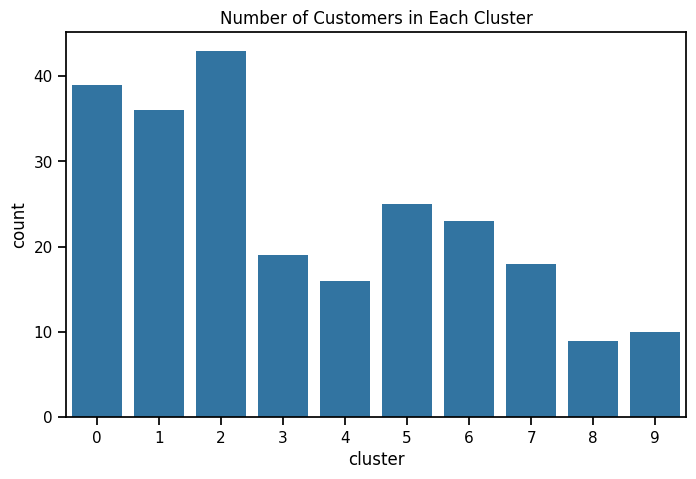

In [18]:
cluster_counts = df["cluster"].value_counts().sort_index()
display(cluster_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="cluster")
plt.title("Number of Customers in Each Cluster")
plt.show()

## 15. Cluster profiling


In [19]:
profile_cols = [resolved[c] for c in ["age", "annual_income", "purchase_amount", "purchase_frequency", "loyalty_score"] if c in resolved]

cluster_profile = df.groupby("cluster")[profile_cols].mean().round(2)
display(cluster_profile)

,age,annual_income,purchase_amount,purchase_frequency,loyalty_score
cluster,,,,,
0,27.74,45435.90,250.51,14.31,4.36
1,41.89,61472.22,479.72,21.53,7.73
2,50.72,70720.93,597.21,25.26,9.00
3,32.68,52631.58,366.32,17.79,5.91
4,23.81,31812.50,168.12,11.00,3.28
5,39.24,59520.00,446.80,20.60,7.18
6,34.83,54565.22,386.96,18.65,6.32
7,47.33,67277.78,545.00,23.28,8.44
8,53.89,73888.89,628.89,27.00,9.39


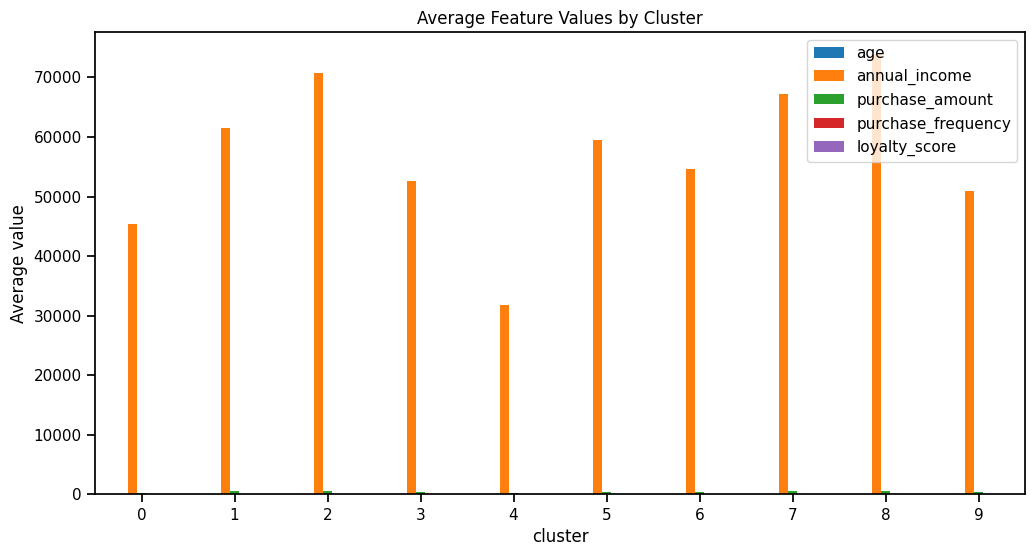

In [20]:
if profile_cols:
    cluster_profile.plot(kind="bar", figsize=(12, 6))
    plt.title("Average Feature Values by Cluster")
    plt.ylabel("Average value")
    plt.xticks(rotation=0)
    plt.show()
else:
    print("No numeric profile columns found.")

## 16. Visualize customer segments in 2D using PCA


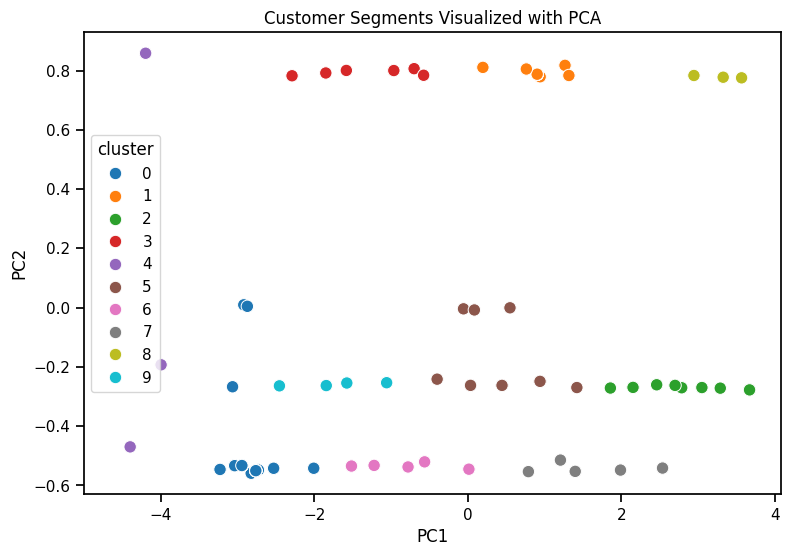

In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

viz_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=80)
plt.title("Customer Segments Visualized with PCA")
plt.show()

## 17. Add simple human-readable segment names


In [22]:
overall_means = df[profile_cols].mean() if profile_cols else pd.Series(dtype=float)

def name_cluster(row, overall):
    tags = []

    if "purchase_amount" in resolved and row.get(resolved["purchase_amount"], 0) >= overall.get(resolved["purchase_amount"], 0):
        tags.append("High Spend")
    else:
        tags.append("Moderate/Low Spend")

    if "purchase_frequency" in resolved and row.get(resolved["purchase_frequency"], 0) >= overall.get(resolved["purchase_frequency"], 0):
        tags.append("Frequent")
    else:
        tags.append("Occasional")

    if "loyalty_score" in resolved:
        if row.get(resolved["loyalty_score"], 0) >= overall.get(resolved["loyalty_score"], 0):
            tags.append("Loyal")
        else:
            tags.append("Less Loyal")

    return " | ".join(tags)

cluster_name_map = {
    cluster_id: name_cluster(cluster_profile.loc[cluster_id], overall_means)
    for cluster_id in cluster_profile.index
}

df["segment_name"] = df["cluster"].map(cluster_name_map)
cluster_name_map

{0: 'Moderate/Low Spend | Occasional | Less Loyal',
 1: 'High Spend | Frequent | Loyal',
 2: 'High Spend | Frequent | Loyal',
 3: 'Moderate/Low Spend | Occasional | Less Loyal',
 4: 'Moderate/Low Spend | Occasional | Less Loyal',
 5: 'High Spend | Frequent | Loyal',
 6: 'Moderate/Low Spend | Occasional | Less Loyal',
 7: 'High Spend | Frequent | Loyal',
 8: 'High Spend | Frequent | Loyal',
 9: 'Moderate/Low Spend | Occasional | Less Loyal'}

In [23]:
segment_summary = df.groupby(["cluster", "segment_name"]).size().reset_index(name="customer_count")
display(segment_summary)

,cluster,segment_name,customer_count
0,0,Moderate/Low Spend | Occasional | Less Loyal,39
1,1,High Spend | Frequent | Loyal,36
2,2,High Spend | Frequent | Loyal,43
3,3,Moderate/Low Spend | Occasional | Less Loyal,19
4,4,Moderate/Low Spend | Occasional | Less Loyal,16
5,5,High Spend | Frequent | Loyal,25
6,6,Moderate/Low Spend | Occasional | Less Loyal,23
7,7,High Spend | Frequent | Loyal,18
8,8,High Spend | Frequent | Loyal,9
9,9,Moderate/Low Spend | Occasional | Less Loyal,10


## 18. Business interpretation


In [24]:
for cluster_id in sorted(df["cluster"].unique()):
    print(f"Cluster {cluster_id} -> {cluster_name_map.get(cluster_id, 'Segment')}")

    if profile_cols:
        row = cluster_profile.loc[cluster_id]
        notes = []

        if "purchase_amount" in resolved:
            if row[resolved["purchase_amount"]] >= overall_means[resolved["purchase_amount"]]:
                notes.append("customers in this segment spend above average")
            else:
                notes.append("customers in this segment spend below or around average")

        if "purchase_frequency" in resolved:
            if row[resolved["purchase_frequency"]] >= overall_means[resolved["purchase_frequency"]]:
                notes.append("they purchase more frequently")
            else:
                notes.append("their purchase frequency is lower")

        if "loyalty_score" in resolved:
            if row[resolved["loyalty_score"]] >= overall_means[resolved["loyalty_score"]]:
                notes.append("their loyalty score is relatively strong")
            else:
                notes.append("their loyalty score is relatively weaker")

        print("- " + "; ".join(notes) + ".")
    print()

Cluster 0 -> Moderate/Low Spend | Occasional | Less Loyal
- customers in this segment spend below or around average; their purchase frequency is lower; their loyalty score is relatively weaker.

Cluster 1 -> High Spend | Frequent | Loyal
- customers in this segment spend above average; they purchase more frequently; their loyalty score is relatively strong.

Cluster 2 -> High Spend | Frequent | Loyal
- customers in this segment spend above average; they purchase more frequently; their loyalty score is relatively strong.

Cluster 3 -> Moderate/Low Spend | Occasional | Less Loyal
- customers in this segment spend below or around average; their purchase frequency is lower; their loyalty score is relatively weaker.

Cluster 4 -> Moderate/Low Spend | Occasional | Less Loyal
- customers in this segment spend below or around average; their purchase frequency is lower; their loyalty score is relatively weaker.

Cluster 5 -> High Spend | Frequent | Loyal
- customers in this segment spend above 

## 19. Save results


In [25]:
output_dir = "customer_segmentation_outputs"
os.makedirs(output_dir, exist_ok=True)

clustered_csv_path = os.path.join(output_dir, "customer_segments.csv")
profile_csv_path = os.path.join(output_dir, "cluster_profile.csv")
model_path = os.path.join(output_dir, "kmeans_model.joblib")
preprocessor_path = os.path.join(output_dir, "preprocessor.joblib")
meta_path = os.path.join(output_dir, "metadata.json")

df.to_csv(clustered_csv_path, index=False)
cluster_profile.to_csv(profile_csv_path)
joblib.dump(kmeans, model_path)
joblib.dump(preprocessor, preprocessor_path)

metadata = {
    "chosen_k": best_k,
    "feature_candidates": feature_candidates,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "cluster_name_map": {str(k): v for k, v in cluster_name_map.items()}
}

with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved files:")
for path in [clustered_csv_path, profile_csv_path, model_path, preprocessor_path, meta_path]:
    print("-", path)

Saved files:
- customer_segmentation_outputs/customer_segments.csv
- customer_segmentation_outputs/cluster_profile.csv
- customer_segmentation_outputs/kmeans_model.joblib
- customer_segmentation_outputs/preprocessor.joblib
- customer_segmentation_outputs/metadata.json


## GitHub Link Placeholder

`https://github.com/anshul55555/Customer-Segmentation.git`